<a href="https://colab.research.google.com/github/Raldulff/SIR-EnKF/blob/main/SIR_EnKF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SIR


## Modelo SIR Determinista


Sistema de Ecuaciones:

$$s'(t) = -\lambda s(t)i(t)$$$$i'(t) = \lambda s(t)i(t) - \gamma i(t)$$$$r'(t) = \gamma i(t)$$


El modelo asume que la comunidad es homogenea y cerrada (sin nacimientos, muertos ni migraciones).

Las funciones representan a las diferentes fracciones de la comunidad:

*   $s(t):$ Es la parte de la poblacion compuesta por individuos susceptibles en el tiempo t. Aquellos que se pueden enfermar

*   $i(t):$ Es la fraccion de la comunidad compuesta por individuos infectados en el tiempo t. Quienes portan la enfermedad y pueden trasmitirla

*   $r(t):$ Es la fracion de la comunidad compuesta por individuos recuperados en el tiempo t. Quienes se recuperaron de la enfermedad, se asume que se vuelven inmunes   

Debido a la que la comunidad es cerrada, para todo $t\geq 0$

$$s(t) + i(t) + r(t) = 1$$

El cambio de las poblaciones esta dado por 2 tasas constantes



*   $\lambda$ **Tasa de infección o contacto:** Este parametro controla el ritmo al que los susceptibles se infectan
*   $\gamma$ **Tasa de recuperacion :** Es la tasa a la que los individuos infecciosos se recuperan y se vuelven inmunes. Por lo que $\frac{1}{\gamma}$ representa el tiempo esperado del periodo de infeccion de una persona

La relacion entre las 2 constantes es el Numero Basico de Reproduccion $(R_0)$, definido como: $$R_0= \frac{\lambda}{\gamma}$$
Este numero representa la cantidad promedio de nuevas infecciones ue causara un indiviiduo infectado antes de su recuperacion.

Siendo que $R_0=1$ es el punto de división entre 2 escenarios distintos.

Si $R_0\leq 1$, es decir una persona infectada contagia a un numero pequeño de personas, entonces la enfermedad no tiene la fuerza para sostenerse y desaparece al poco tiempo, conocido como un brote menor

Si $R_0 \geq 1 $, es decir si un individuo contagia a más de una persona, el brote tiene la capacidad de multiplicarse e infectar a una gran parte de la comunidad

El modelo SIR determinista presenta limitaciones clave que no lo hacen el más confiable, lo siguiente es una lista de eso:

*    El modelo aunque asumiendo homogeneidad, este no es bueno para modelar poblaciones pequeñas

*    Si el $R_0 > 1$ el modelo asume que  el brote se esparcirá , sin embargo es posible que la enfermedad no se extienda debido al número de infectados iniciales

*    El modelo no toma el cuneta la variabilidad demográfica o ambiental

*    El modelo asume la homogeneidad y

## SEIR
El modelo SEIR es una extension del modelo SIR, el cual divide a la poblacion en 4 grupos de personas $S$ suceptibles, $E$ expuestos, $I$ Infecciosos, $R$ recuperados, y obedecen al siguiente sistema de ecuaciones:

$$\frac{dS}{dt} = b(N-S)-\beta SI$$

$$\frac{dE}{dt} = \beta SI -\sigma E - bE$$

$$\frac{dI}{dt} = \sigma E - bI - \gamma I$$

$$\frac{dR}{dt} =\gamma I - bR$$

En donde:
* $b:=$ Tasa de natalidad y mortalidad, representa que tan rapido nacen y mueren las personas pro causas ajenas a la enfermedad
* $\beta:=$ Tasa de transmisión, representa que tan efectivo es que un contacto resulte en una infeccion
* $\sigma:=$ Tasa de progresión, velocidad en la que un individuo pas ade estar expuesto a estar infeccioso, el inverso puede verse como el tiempo de incubacion de la enfermedad
* $\gamma:=$ Tasa de recuperacion, es la veloidad a la que los infecciosos se curan.

La suma de $S(t)+E(t)+I(t)+R(t)=N$ da como resultado la poblacion total.

La primera ecuacion representa a los susceptibles, es decir,  los sujetos que nacen, menos los susceptibles que mueren por cosas ajenas a la infeccion, menos las personas que se contagian por estar en contacto con las personas infectadas.

La segunda ecuacion, representa a las personas expuestas, compuesta por aquellos que se contagiaron, menos las que ya terminaron el periodo de incubacion y se vuelven contagiosas, menos las que mueren por causas naturales

La tercera ecuacion, los infectados, compuesta por las personas que terminaron su periodo de incubacion, menos las que murieron de forma ajena a la infeccion, menos las personas que se recuperan de la enfermmedad.

El numero basico de Reproduccion $(R_0)$

definido como:

$$R_0=\left(\frac{\beta N}{\gamma + b}\right) \left( \frac{\sigma}{\sigma + b}\right)$$

Explica a cuantas personas contagiara un "paciente cero"
* La probabilidad de sobrevivir a la incubacion $\left( \frac{\sigma}{\sigma + b}\right)$, es la probabilidad de que un individuo llegue a la fase infeccioa en lugar de morir.
* El potencial de contagio $\left(\frac{\beta N}{\gamma + b}\right)$, si el paciente se vuelve infeccioso, esto nos dira a cuantas perosnas va a contagiar.


## SEIRD

El modelo SEIRD divide a la poblacion total $N$ en 5 partes: Susceptibles ($S$), Expuestos ($E$), Infectados ($I$), Recuperados ($R$), y Muestos/Fallecidos ($D$), obedeciendo el siguiente sistema de ecuaciones diferenciales:

$$\frac{dS}{dt} = -\frac{\beta SI}{N} $$

$$\frac{dE}{dt} = \frac{\beta SI}{N}- \alpha E $$

$$\frac{dI}{dt} = \alpha E - \gamma I - \delta I$$

$$\frac{dR}{dt} = \gamma I $$

$$\frac{dD}{dt} = \delta I $$

En donde:
* $\beta$ (Tasa de transmision): la probabilidad de que el contacto entre una persona susceptible y una infectada resulte en exposicion al virus
* $\alpha$ (Tasa de progresion/conversion): representa la velocidad a la que los individuos expuestos desarrollan la enfermedad y pasan a ser infectados. El inverso es el periodo de incubacion
* $\gamma$ (Tasa de recuperacion): es la vvelocidad a la que los infectados se recuperan
* $\delta$ (Tasa de mortalidad): tasa a la que los individuos infectados fallecen

Ecuaciones:

$\frac{dS}{dt}$, los susceptibles disminuyen al entrar en contacto con los infectados

$\frac{dE}{dt}$, los expuestos crecen an la proporcion en la que los susceptibles se contagian, pero disminuyen a una tasa $\alpha$ a medida que la enfermedad se desarrolla y se vuelven infectados

$\frac{dI}{dt}$, Los infectados aumentan gracias a los que llegan de la etapa de exposicion , mientras decrece por las personas que se recuperan y las que fallecen

$\frac{dR}{dt}$, los recuperados incrementan por la poblacion que sale de la infeccion a una tasa $\gamma$

$\frac{dD}{dt}$, las muertes  acumuladas por las personas que no pudieron recuperarse durante el contagio

### Numero de Reproduccion Basico ($R_0$)

Al igual que en los modelos SIR y SEIR, $R_0$ nos indicara si una epodemia se extingira o se propagara
Para el modelo SEIRD, $R_0$ se define como:
$$R_0=\left(\frac{\beta}{\gamma + \delta} \right) $$
PUes cada individuo genera contagios durante el tiempo que pasa en $I$, y se acaba cuando sale, ya sea por recuperacion o muerte.

### Ventajas

Al incluir la curva de fallecidos nos da una mayor informacion para la toma de decisiones y la gravedad de la cepa






# Codigo

In [ ]:
!pip install dapper
import numpy as np
import matplotlib as mpl
import numpy.random as rnd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from dapper.mods.integration import rk4
import numpy.linalg as nla
from scipy.integrate import solve_ivp
import ipywidgets as widgets
from IPython.display import display

INFO: pip is looking at multiple versions of pathos to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 330.2/330.2 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.1/82.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 2.7 MB/s eta 0:00:00
  Attempting uninstall: tabulate
    Found existing installation: tabulate 0.9.0
    Uninstalling tabulate-0.9.0:
      Successfully uninstalled tabulate-0.9.0
  Attempting uninstall: notebook
    Found existing installation: notebook 6.5.7
    Uninstalling notebook-6.5.7:
      Successfully uninstalled notebook-6.5.7
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the fol

## Modelo SIR analisis

In [ ]:
# modelo SIR
def sir(t, estados, l, g):

  s, i, r = estados
  ds = -l*s*i
  di = l*s*i - g*i
  dr = g*i

  return [ds, di, dr]

def graf_sir(l, g):

  #condiciones iniciales
  t = (0,50)
  t_eval = np.linspace(0,50,500)
  estados_0 = [0.99, 0.01, 0]

  #solucion inicial
  sol = solve_ivp(sir, t, estados_0, args=(l, g), t_eval=t_eval)

  #grafica
  plt.figure()
  plt.plot(sol.t, sol.y[0], 'b--', label='Susceptibles')
  plt.plot(sol.t, sol.y[1], 'r--', label='Infectados')
  plt.plot(sol.t, sol.y[2], 'g-', label='Recuperados')

  R0 = l/g
  plt.title(f'Modelo SIR Determinista ($R_0$ = {R0:.2f})')
  plt.xlabel('Tiempo')
  plt.ylabel('Fracción de la población')
  plt.legend()
  plt.show()

In [ ]:
#crear slider
l_slider = widgets.FloatSlider(value=0.7,min=0.05,max=5,step=0.05,description='Contacto (λ):')
g_slider = widgets.FloatSlider(value=0.5,min=0.05,max=5,step=0.01,description='Rec (γ):')

widgets.interact(graf_sir, l=l_slider, g=g_slider)

interactive(children=(FloatSlider(value=0.7, description='Contacto (λ):', max=5.0, min=0.05, step=0.05), Float…

<function __main__.graf_sir(l, g)>

## Primer Intento del EnKF


In [ ]:

xDim = 3

def dxdt(x, beta=0.3, gamma=0.1):

    S, I, R = x
    d = np.zeros(3)
    d[0] = -beta * S * I
    d[1] = beta * S * I - gamma * I
    d[2] = gamma * I
    return d

def Dyn(E, t0, dt):
    def step(x0):
        return rk4(lambda x, t: dxdt(x), x0, t0, dt)

    if E.ndim == 1:
        E = step(E)
    else:
        for n in range(E.shape[1]):
            E[:, n] = step(E[:, n])
    return E

Q12 = np.zeros((xDim, xDim))
Q = Q12 @ Q12.T

In [ ]:
dt = 0.1
dko = 20
dto = dko*dt
Ko = 40
nTime = dko*(Ko+1)

xa = np.array([0.99, 0.01, 0.0])
Pa12 = np.diag([0.05, 0.02, 0.0])

p = 1
obs_idx = 1

def Obs(E, t, obs_idx):

    return E[obs_idx:obs_idx+1] if E.ndim == 1 else E[obs_idx:obs_idx+1, :]

R12 = np.array([[0.02]])
R = R12 @ R12.T


In [ ]:
truths = np.zeros((nTime+1, xDim))
obsrvs = np.zeros((Ko+1, p))
truths[0] = xa + Pa12 @ rnd.randn(xDim)
truths[0] = np.clip(truths[0], 0, 1)
for k in range(1, nTime+1):
    truths[k] = Dyn(truths[k-1], (k-1)*dt, dt)
    truths[k] += Q12 @ rnd.randn(xDim)

    if k % dko == 0:
        obs_k = k//dko-1
        obsrvs[obs_k] = Obs(truths[k], np.nan) + R12 @ rnd.randn(p)
        obsrvs[obs_k] = np.maximum(obsrvs[obs_k], 0)

In [ ]:
ens_means = np.zeros((nTime+1, xDim))
ens_vrncs = np.zeros((nTime+1, xDim))

def my_EnKF(N):
    """Filtro de Kalman por Ensambles para modelo SIR"""
    ### Init ###
    E = xa[:, None] + Pa12 @ rnd.randn(xDim, N)
    E = np.clip(E, 0, 1)

    for k in tqdm(range(1, nTime+1)):
        t = k*dt

        E = Dyn(E, t-dt, dt)
        E += Q12 @ rnd.randn(xDim, N)

        if k % dko == 0:
            #
            y = obsrvs[[k//dko-1]].T
            Eo = Obs(E, t)

            #
            Y = Eo - Eo.mean(keepdims=True)
            X = E - E.mean(keepdims=True)
            PH = X @ Y.T / (N-1)
            HPH = Y @ Y.T / (N-1)

            #
            KG = nla.solve(HPH + R, PH.T).T
            Perturbs = R12 @ rnd.randn(p, N)

            #
            E += KG @ (y - Eo - Perturbs)
            E = np.clip(E, 0, 1)

        ens_means[k] = np.mean(E, axis=1)
        ens_vrncs[k] = np.var(E, axis=1, ddof=1)

  0%|          | 0/820 [00:00<?, ?it/s]

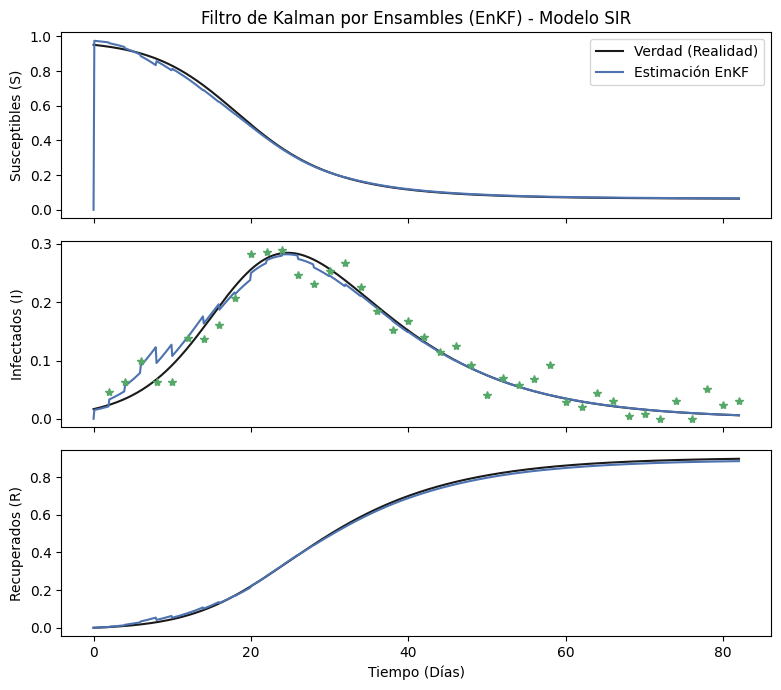

In [ ]:
my_EnKF(50)

fig, axs = plt.subplots(nrows=3, sharex=True, figsize=(8, 7))
labels = ['Susceptibles (S)', 'Infectados (I)', 'Recuperados (R)']

for i in range(3):
    axs[i].plot(dt*np.arange(nTime+1), truths[:, i], 'k', label="Verdad (Realidad)")
    axs[i].plot(dt*np.arange(nTime+1), ens_means[:, i], 'b', label="Estimación EnKF")

    # Solo graficar observaciones en el panel de 'Infectados'
    if i == obs_idx:
        axs[i].plot(dto*np.arange(1, Ko+2), obsrvs[:, 0], 'g*', label="Datos Clínicos")

    axs[i].set_ylabel(labels[i])

axs[0].set_title("Filtro de Kalman por Ensambles (EnKF) - Modelo SIR")
axs[0].legend()
plt.xlabel("Tiempo (Días)")
plt.tight_layout()
plt.show()

## Modificacion de EnKF

In [ ]:
# modificacion de la funcion my_EnKF, buscando universalidad

def EnKF(N, xDim, p, Dyn_f, Obs_f, xa, Pa12, Q12, R12, obsrvs, nTime, dt, dko, obs_idx ):

  # calculo de la matriz R
  R= R12 @ R12.T
  # arreglos para guardar las estadisticas
  ens_means = np.zeros((nTime+ 1, xDim))
  ens_vrncs = np.zeros((nTime+1, xDim))

  #Inicializacion del ensamble
  E = xa[:, None] + Pa12 @ rnd.randn(xDim, N)
  E = np.clip(E, 0, 1)
  #ens_means[0] = np.mean(E, axis=1)
  #ens_vrncs[0] = np.var(E, axis=1, ddof=1)

  #ciclo principal
  for k in tqdm(range(1, nTime+1)):
      t = k*dt

      # pronostico
      E = Dyn_f(E, t-dt, dt)
      E += Q12 @ rnd.randn(xDim, N)

      # analisis
      if k % dko == 0:

          y = obsrvs[[k//dko-1]].T
          Eo = Obs_f(E, t, obs_idx)

          # momentos del ensamble
          Y = Eo - Eo.mean(keepdims=True)
          X = E - E.mean(keepdims=True)
          PH = X @ Y.T / (N-1)
          HPH = Y @ Y.T / (N-1)

          # ganancia de kalman y perturbaciones
          KG = nla.solve(HPH + R, PH.T).T
          Perturbs = R12 @ rnd.randn(p, N)

          # actualizacion
          E += KG @ (y - Eo - Perturbs)
          E = np.clip(E, 0, 1.0) # Mantener poblaciones entre 0 y 1

      ens_means[k] = np.mean(E, axis=1)
      ens_vrncs[k] = np.var(E, axis=1, ddof=1)

  return ens_means, ens_vrncs

In [ ]:
# Funcion que grafica

def plot_enkf(truths, means, vars, obrsvs, dt, dko, obs_idx , labels, title="Resultados EnKF"):
  if isinstance(obs_idx, int):
    obs_idx = [obs_idx]

  nTime = truths.shape[0]-1
  xDim = truths.shape[1]
  ko = obrsvs.shape[0]-1

  # ejes
  t_full = dt * np.arange(nTime + 1)
  t_obs = (dt * dko) * np.arange(1, ko + 2)

  # paleta de colores para modelos grandes
  cmap =plt.get_cmap('tab10')

  # figura
  fig, axs = plt.subplots(nrows=xDim, sharex=True, figsize=(8, 2.5 * xDim))

  if xDim == 1:
    axs = [axs]

  # graficas
  for i in range(xDim):
    c=cmap(i % 10)

    # grafica de las verdades
    axs[i].plot(t_full, truths[:, i], 'k-', label="Realidad")

    #grafica media del EnKF
    axs[i].plot(t_full, means[:, i], color = c, label="Estimación EnKF")

    # grafica incertidumbre
    std_dev = np.sqrt(vars[:, i])
    axs[i].fill_between(t_full,
                        means[:, i] - std_dev,
                        means[:, i] + std_dev,
                        color=c, alpha=0.2, label= "Incertidumbre" )

    # grafica de observaciones
    if i in obs_idx:
      obs_col = obs_idx.index(i)
      axs[i].plot(t_obs, obrsvs[:, obs_col], 'k*', label="Observaciones")

    axs[i].set_ylabel(labels[i])
    axs[i].grid(True, linestyle='--', alpha=0.6)
    if i == 0:
      axs[i].set_title(title)
      axs[i].legend()

  # grafica
  plt.xlabel("Tiempo")
  plt.tight_layout()
  plt.show()

In [ ]:
#grafica de la Raiz del Error Cuadrado Medio (RMSE)
def plot_rmse(truths, means, dt, dko, title="RMSE EnKF"):

  nTime = truths.shape[0]-1
  t_full = dt * np.arange(nTime + 1)

  # calculo del rmse en cada innstante de tiempo
  rmse_t = np.sqrt(np.mean((truths - means)**2, axis=1))

  # configuracion de la grfica
  plt.figure(figsize=(10, 4))

  # linea principal del error
  plt.plot(t_full, rmse_t, 'r-', label="RMSE EnKF")

  # marcas en los momentos de asimilacion
  if dko is not None:
    # tiempo donde ocurrio la observacion
    t_obs = (dko * dt) * np.arange(1, (nTime // dko) + 1)

    for i, to in enumerate(t_obs):
      label = 'Asimilacion de Datos' if i == 0 else None
      plt.axvline(x=to, color='green', linestyle='--', label=label)

  plt.xlabel("Tiempo")
  plt.ylabel("RMSE")
  plt.title(title)
  plt.grid(True, linestyle=':', alpha=0.6)
  plt.legend()

  plt.ylim(bottom=0)
  plt.tight_layout()
  plt.show()

  rmse_global = np.mean(rmse_t)
  print(f"RMSE Global: {rmse_global:.4f}")

  return rmse_global

## Modelos con EnKF

In [ ]:
# SIR(det) EnKF

#modelo SIR
def dxdt_sir(x, beta=0.3, gamma=0.1):
    S, I, R = x
    d = np.zeros(3)
    d[0] = -beta * S * I
    d[1] = beta * S * I - gamma * I
    d[2] = gamma * I
    return d

#  modelo pronostico x(t+dt) = M(x(t),t,dt), usando 4th order Runge-Kutta
def Dyn_sir (E, t0, dt):
    def step(x0):
        return rk4(lambda x, t: dxdt_sir(x), x0, t0, dt)

    if E.ndim == 1:
        E = step(E)
    else:
        for n in range(E.shape[1]):
            E[:, n] = step(E[:, n])
    return E

# extraccion de una fila correspondiente
def Obs(E, t, obs_idx):

    return E[obs_idx:obs_idx+1] if E.ndim == 1 else E[obs_idx:obs_idx+1, :]


xDim_sir = 3    # dimension del modelo
p_sir = 1       # dimension de la observacion
obs_idx_sir = 1 # indice de observacion

#paremetros del experimento
dt_sir = 0.1 # paso de tiempo de integracion
dko_sir = 20 # numero de pasos entre observaciones
dt0_sir = dko_sir*dt_sir # tiempo entre observaciones
Ko_sir = 50  # numero de observaciones
nTime_sir = dko_sir*(Ko_sir+1)# tiempo entre observaciones

#condiciones iniciales
# proporcion de cada poblacion
xa_sir = np.array([0.98, 0.01, 0.0])
# raiz cuadrada de la matriz de covarianza
Pa12_sir = np.diag([0.05, 0.2, 0.0]) #nivel de confianza en la poblacion
# raiz cuadrada de la matriz de covarianza del error del modelo
Q12_sir = np.zeros((xDim_sir, xDim_sir))
# raiz cuadrada de los erorres de los sensores
R12_sir =np.array ([[0.02]])

# vectores para guardar thruths y obsrvs
truths_sir = np.zeros((nTime_sir+1, xDim_sir))
obsrvs_sir = np.zeros((Ko_sir+1, p_sir))
truths_sir[0] = xa_sir + Pa12_sir @ rnd.randn(xDim_sir)
truths_sir[0] = np.clip(truths_sir[0], 0, 1)

# ciclo que genera observaciones sinteticas
for k in range(1, nTime_sir+1):
    truths_sir[k] = Dyn_sir(truths_sir[k-1], (k-1)*dt_sir, dt_sir)
    truths_sir[k] += Q12_sir @ rnd.randn(xDim_sir)

    if k % dko_sir == 0:
        obs_k = k//dko_sir-1
        obsrvs_sir[obs_k] = Obs(truths_sir[k], np.nan,obs_idx_sir ) + R12_sir @ rnd.randn(p_sir)
        obsrvs_sir[obs_k] = np.maximum(obsrvs_sir[obs_k], 0) # Observación >= 0

In [ ]:
# Implementacion del modelo SEIR

#modelo SEIR
def dxdt_SEIR(x, beta=0.5,sigma=0.2, gamma=0.1, b=0.01, N_pop=1.0):
    S, E, I, R = x
    d = np.zeros(4)
    # dS/dt = b(N-S) - beta*S*I
    d[0] = b * (N_pop - S) - beta * S * I
    # dE/dt = beta*S*I - sigma*E - b*E
    d[1] = beta * S * I - sigma * E - b * E
    # dI/dt = sigma*E - b*I - gamma*I
    d[2] = sigma * E - b * I - gamma * I
    # dR/dt = gamma*I - b*R
    d[3] = gamma * I - b * R
    return d

#  modelo pronostico x(t+dt) = M(x(t),t,dt), usando 4th order Runge-Kutta
def Dyn_SEIR(E, t0, dt):
  def step(x0):
    return rk4(lambda x, t: dxdt_SEIR(x), x0, t0,dt)
  if E.ndim == 1: return step(E)
  for n in range(E.shape[1]):
    E[:, n] = step(E[:, n])
  return E

xDim_seir = 4 # dimension del modelo
p_seir = 1 #numero de dimensiones observadas
obs_idx_seir = 2

#paremetros del experimento
dt_seir = 0.1 # paso de tiempo de integracion
dko_seir = 20 # numero de pasos entre observaciones
dt0_seir = dko_seir*dt_seir # tiempo entre observaciones
Ko_seir = 50  # numero de observaciones
nTime_seir = dko_seir*(Ko_seir+1)# tiempo entre observaciones

#condiciones iniciales
# proporcion de cada poblacion
xa_seir = np.array([0.98, 0.01, 0.1, 0.0])
# raiz cuadrada de la matriz de covarianza
Pa12_seir = np.diag([0.05, 0.02, 0.2, 0.0]) #nivel de confianza en la poblacion
# raiz cuadrada de la matriz de covarianza del error del modelo
Q12_seir = np.zeros((xDim_seir, xDim_seir))
# raiz cuadrada de los erorres de los sensores
R12_seir =np.array ([[0.02]])

# vectores para thruths y obsrvs
truths_seir = np.zeros((nTime_seir+1, xDim_seir))
obsrvs_seir = np.zeros((Ko_seir+1, p_seir))
truths_seir[0] = xa_seir + Pa12_seir @ rnd.randn(xDim_seir)
truths_seir[0] = np.clip(truths_seir[0], 0, 1)

#ciclo que genera observaciones sinteticas
for k in range(1, nTime_seir+1):
    truths_seir[k] = Dyn_SEIR(truths_seir[k-1], (k-1)*dt_seir, dt_seir)
    truths_seir[k] += Q12_seir @ rnd.randn(xDim_seir)

    if k % dko_seir == 0:
        obs_k = k//dko_seir-1
        obsrvs_seir[obs_k] = Obs(truths_seir[k], np.nan, obs_idx_seir) + R12_seir @ rnd.randn(p_seir)
        obsrvs_seir[obs_k] = np.maximum(obsrvs_seir[obs_k], 0)

In [ ]:
# Implementacion del modelo SEIRD clasico
def dxdt_SEIRD(x, beta=0.5, alpha=0.2, gamma=0.1, delta=0.01, N_pop=1.0):
  S, E, I, R, D = x
  d = np.zeros(5)

  d[0]=-beta * S * I / N_pop
  d[1]= beta * S * I/ N_pop - alpha * E
  d[2]= alpha * E - (gamma + delta) * I
  d[3]= gamma * I
  d[4]= delta * I
  return d

def Dyn_SEIRD(E, t0, dt):
  def step(x0):
    return rk4(lambda x, t: dxdt_SEIRD(x), x0, t0,dt)
  if E.ndim == 1:
    return step(E)
  for n in range(E.shape[1]):
    E[:, n] = step(E[:, n])
  return E

def Obs_SEIRD(E, t, obs_idx):
  return E[obs_idx] if E.ndim == 1 else E[obs_idx, :]

#Configuracion del experimento
xDim_seird = 5 # dimension del modelo
p_seird = 3    # numero de dimensiones observadas
# indices observados: I(2) , R (3), D (4)
obs_idx_seird = [2, 3, 4]

# parametros del tiempo
dt_seird = 0.1             # paso de tiempo de integracion
dko_seird = 20             # numero de pasos entre observaciones
dt0_seird = dko_seird * dt_seird # tiempo entre observaciones
Ko_seird = 50              # número de observaciones
nTime_seird = dko_seird * (Ko_seird + 1) # tiempo total de simulación

# Condiciones iniciales (S, E, I, R, D)
xa_seird = np.array([0.98, 0.01, 0.01, 0.0, 0.0])

# raiz cuadrada de la matriz de covarianza
Pa12_seird = np.diag([0.05, 0.02, 0.02, 0.0, 0.0])

# raiz cuadrada de la covarianza del error del modelo (Asumimos modelo perfecto por ahora)
Q12_seird = np.zeros((xDim_seird, xDim_seird))

# raiz cuadrada de los errores de los sensores
R12_seird = np.diag([0.02, 0.02, 0.01])

# generacion del mundo real y observaciones sinteticas
# vectores para truths y obsrvs
truths_seird = np.zeros((nTime_seird + 1, xDim_seird))
obsrvs_seird = np.zeros((Ko_seird + 1, p_seird))

# perturbacion de la condicion inicial real
truths_seird[0] = xa_seird + Pa12_seird @ rnd.randn(xDim_seird)
truths_seird[0] = np.clip(truths_seird[0], 0, 1)

# Ciclo que genera las verdades y observaciones sinteticas
for k in range(1, nTime_seird + 1):
    truths_seird[k] = Dyn_SEIRD(truths_seird[k-1], (k-1)*dt_seird, dt_seird)
    truths_seird[k] += Q12_seird @ rnd.randn(xDim_seird)

    if k % dko_seird == 0:
        obs_k = k // dko_seird - 1


        observacion_limpia = Obs_SEIRD(truths_seird[k], np.nan, obs_idx_seird)
        ruido_sensor = R12_seird @ rnd.randn(p_seird)

        obsrvs_seird[obs_k] = observacion_limpia + ruido_sensor

        obsrvs_seird[obs_k] = np.maximum(obsrvs_seird[obs_k], 0)

In [ ]:
# Implementacion del modelo SEIRD clasico asimilacion sobre I


#Configuracion del experimento
xDim_seird_0 = 5 # dimension del modelo
p_seird_0 = 1    # numero de dimensiones observadas
# indices observados: I(2) , R (3), D (4)
obs_idx_seird_0 = 2

# parametros del tiempo
dt_seird_0 = 0.1             # paso de tiempo de integracion
dko_seird_0 = 20             # numero de pasos entre observaciones
dt0_seird_0 = dko_seird_0 * dt_seird_0 # tiempo entre observaciones
Ko_seird_0 = 50              # número de observaciones
nTime_seird_0 = dko_seird_0 * (Ko_seird_0 + 1) # tiempo total de simulación

# Condiciones iniciales (S, E, I, R, D)
xa_seird_0 = np.array([0.98, 0.01, 0.01, 0.0, 0.0])

# raiz cuadrada de la matriz de covarianza
Pa12_seird_0 = np.diag([0.05, 0.02, 0.02, 0.0, 0.0])

# raiz cuadrada de la covarianza del error del modelo (Asumimos modelo perfecto por ahora)
Q12_seird_0 = np.zeros((xDim_seird_0, xDim_seird_0))

# raiz cuadrada de los errores de los sensores
R12_seird_0 = np.array ([[0.02]])

# generacion del mundo real y observaciones sinteticas
# vectores para truths y obsrvs
truths_seird_0 = np.zeros((nTime_seird_0 + 1, xDim_seird_0))
obsrvs_seird_0 = np.zeros((Ko_seird_0 + 1, p_seird_0))


# perturbacion de la condicion inicial real
truths_seird_0[0] = xa_seird_0 + Pa12_seird_0 @ rnd.randn(xDim_seird_0)
truths_seird_0[0] = np.clip(truths_seird_0[0], 0, 1)

# Ciclo que genera las verdades y observaciones sinteticas
for k in range(1, nTime_seird_0 + 1):
    truths_seird_0[k] = Dyn_SEIRD(truths_seird_0[k-1], (k-1)*dt_seird_0, dt_seird_0)
    truths_seird_0[k] += Q12_seird_0 @ rnd.randn(xDim_seird_0)


    if k % dko_seird_0 == 0:
        obs_k = k // dko_seird_0 - 1


        obsrvs_seird_0[obs_k] = Obs(truths_seird_0, np.nan, obs_idx_seird_0) + R12_seird_0 @ rnd.randn(p_seird_0)

        obsrvs_seird_0[obs_k] = np.maximum(obsrvs_seird_0[obs_k], 0)

ValueError: could not broadcast input array from shape (5,) into shape (1,)

  0%|          | 0/1020 [00:00<?, ?it/s]

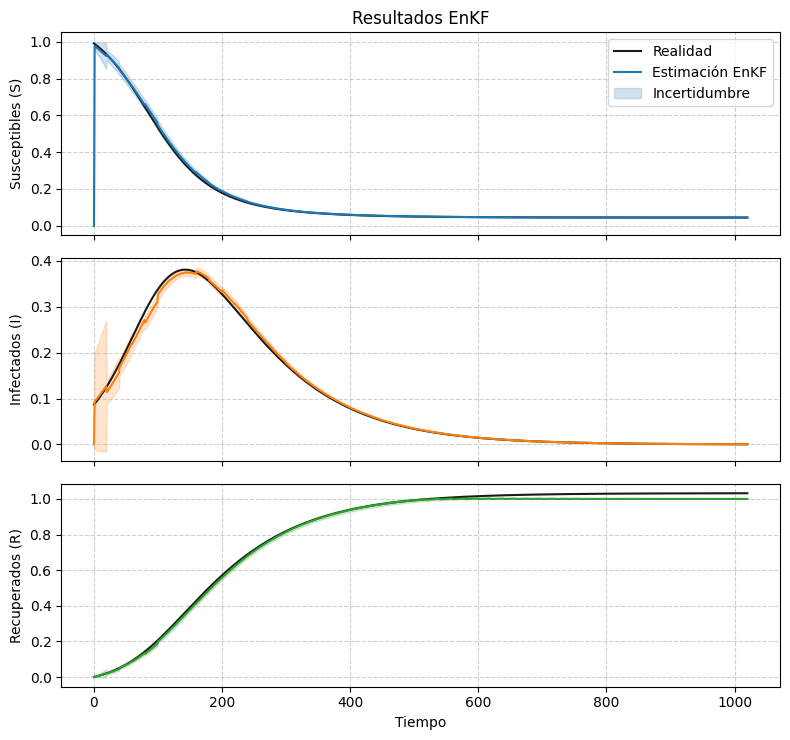

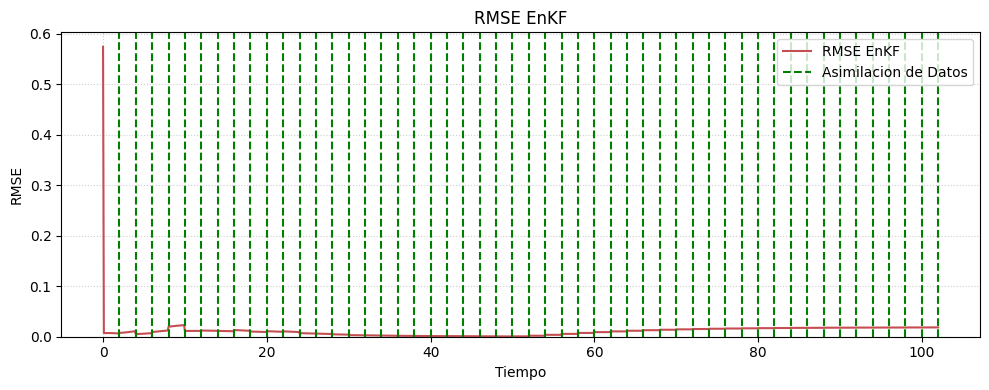

RMSE Global: 0.0107


In [ ]:
# llamado al EnKF, Gaficas y RMSE, usando el modelo SIR

means_sir,vars_sir = EnKF(20, xDim_sir, p_sir, Dyn_sir, Obs, xa_sir,
                          Pa12_sir, Q12_sir, R12_sir, obsrvs_sir,
                          nTime_sir, dt_sir, dko_sir, obs_idx_sir)

labels_sir = ['Susceptibles (S)', 'Infectados (I)', 'Recuperados (R)']
plot_enkf(truths_sir, means_sir, vars_sir, obsrvs_sir, obs_idx_sir ,dt_sir, dko_sir, labels_sir)
rmse_sir = plot_rmse(truths_sir, means_sir, dt_sir, dko_sir)

  0%|          | 0/1020 [00:00<?, ?it/s]

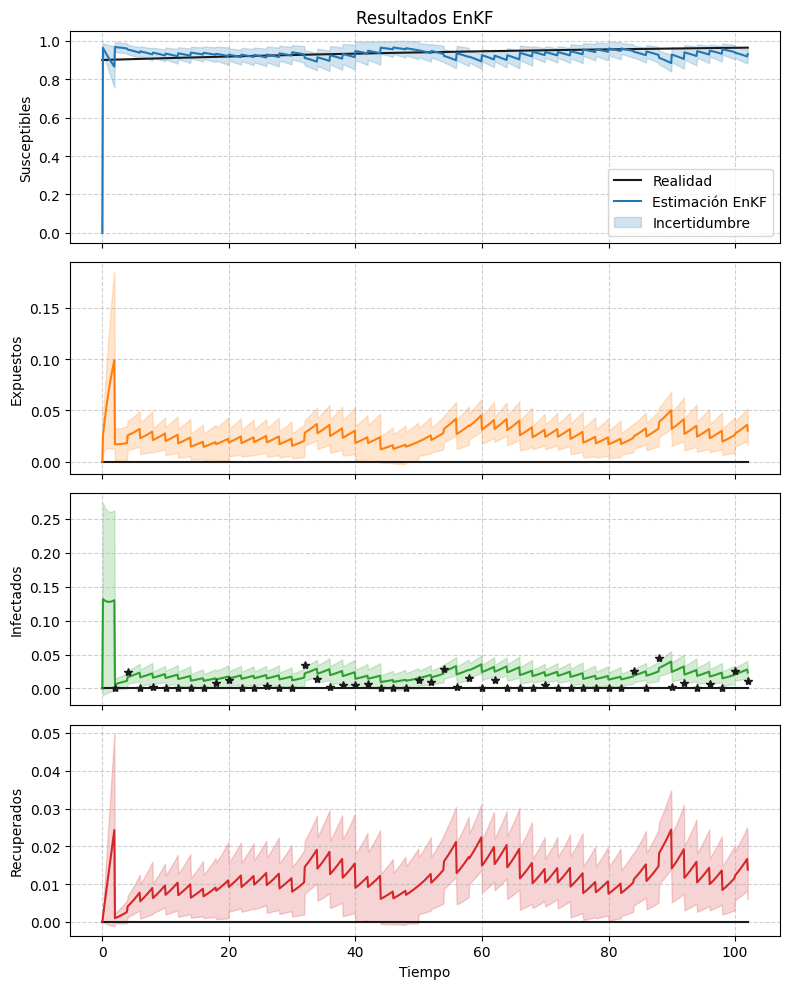

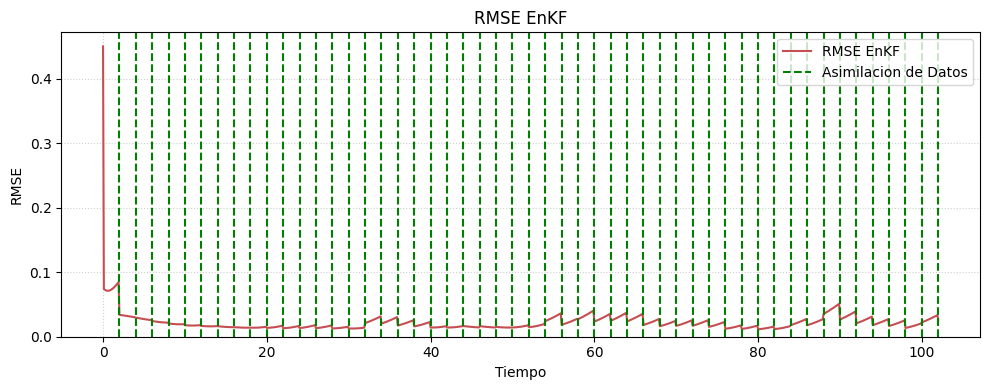

RMSE Global: 0.0221


In [ ]:
# llamado al EnKF, Gaficas y RMSE, usando el modelo SEIR
means_seir,vars_seir = EnKF(20, xDim_seir, p_seir, Dyn_SEIR, Obs, xa_seir,
                          Pa12_seir, Q12_seir, R12_seir, obsrvs_seir,
                          nTime_seir, dt_seir, dko_seir, obs_idx_seir)
labels_seir = ['Susceptibles', 'Expuestos', 'Infectados', 'Recuperados']
plot_enkf(truths_seir, means_seir, vars_seir, obsrvs_seir, dt_seir, dko_seir,
          obs_idx_seir, labels_seir)
rmse_seir = plot_rmse(truths_seir, means_seir, dt_seir, dko_seir)

In [ ]:
#Asimilacio de datos con el modelo SEIRD
means_seird, vars_seird = EnKF(1500, xDim_seird, p_seird, Dyn_SEIRD, Obs_SEIRD,
                          xa_seird, Pa12_seird, Q12_seird, R12_seird, obsrvs_seird,
                          nTime_seird, dt_seird, dko_seird, obs_idx_seird)


  0%|          | 0/1020 [00:00<?, ?it/s]

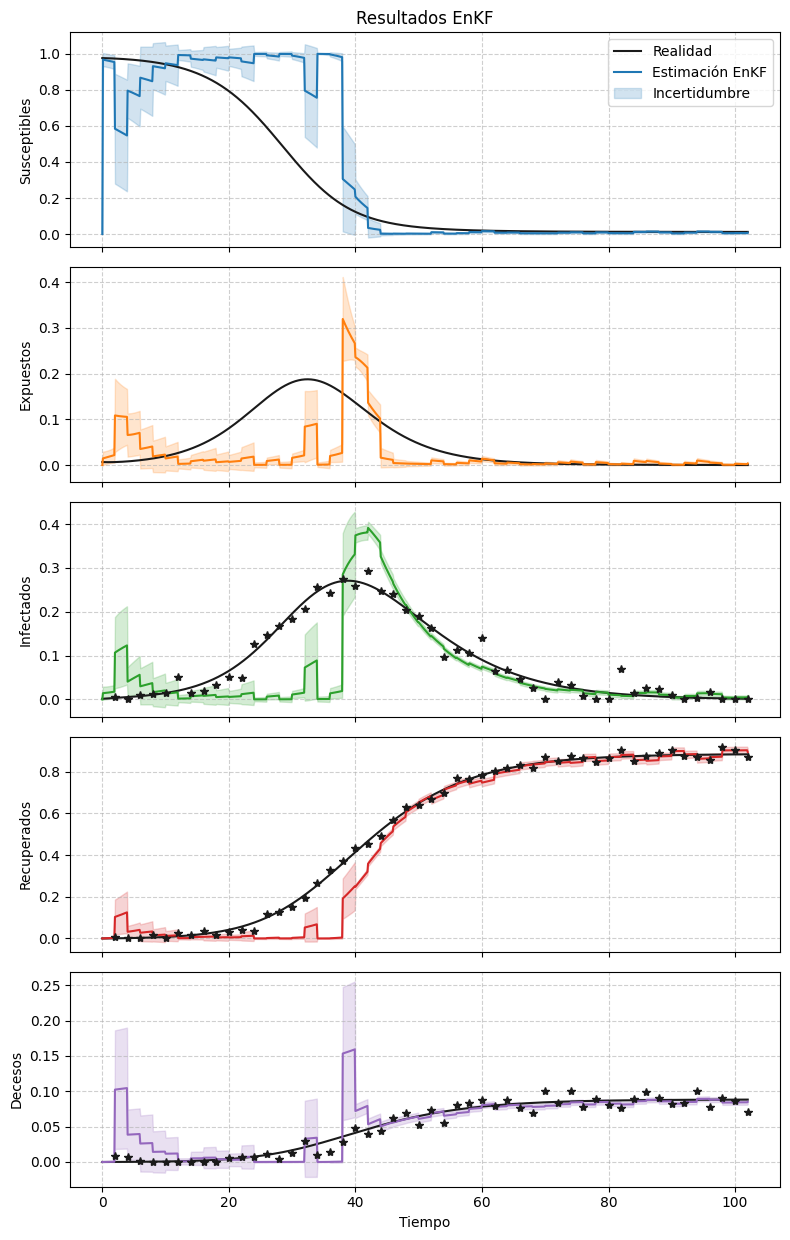

In [ ]:
#grafica de la asimilacion con el modelo SEIRD
labels_seird = ['Susceptibles', 'Expuestos', 'Infectados', 'Recuperados',
'Decesos']
plot_enkf(truths_seird, means_seird, vars_seird, obsrvs_seird,
          dt_seird, dko_seird, obs_idx_seird, labels_seird)



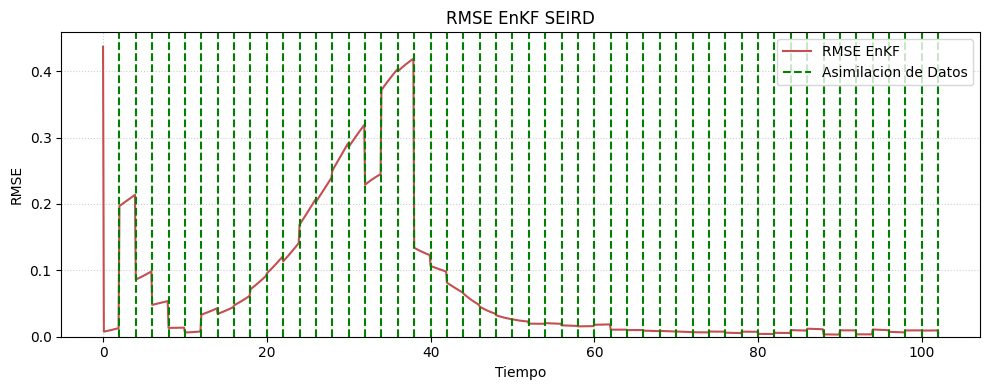

RMSE Global: 0.0698


In [ ]:
# RMSE para el SEIRD
rmse_seird = plot_rmse(truths_seird, means_seird, dt_seird, dko_seird, title="RMSE EnKF SEIRD")

In [ ]:
#Asimilacio de datos con el modelo SEIRD
means_seird, vars_seird = EnKF(100, xDim_seird, p_seird_0, Dyn_SEIRD, Obs_SEIRD,
                          xa_seird, Pa12_seird, Q12_seird, R12_seird, obsrvs_seird,
                          nTime_seird, dt_seird, dko_seird, obs_idx_seird_0)


  0%|          | 0/1020 [00:00<?, ?it/s]

ValueError: solve1: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (m,m),(m)->(m) (size 5 is different from 1)